## Task 1: Data Loading and Initial Inspection

Load the dataset (e.g., using pandas in Python).

In [1]:
import pandas as pd

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv"

In [3]:
titanic_df = pd.read_csv(url)

Display the first 5 rows to get a quick look at the data structure.

In [4]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Check the data types of all columns (.info()).

In [5]:
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Get descriptive statistics of the numerical columns (.describe()).

In [6]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Identify the total number of missing values for each column.

In [7]:
titanic_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Task 2: Univariate Analysis

Univariate analysis looks at a single variable at a time.

---



In [8]:
titanic_df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

#### Survival Rate:

Calculate the overall survival rate (percentage of passengers who survived).:

In [9]:
total_survived = titanic_df['Survived'].sum()
total_passengers = titanic_df['Survived'].count()
print(f"Survival Rate: {(total_survived / total_passengers)*100:.2f}%")

Survival Rate: 38.38%


In [10]:
# Another Way

print(f"Survival Rate: {titanic_df['Survived'].mean()*100:.2f}%")

Survival Rate: 38.38%


Visualize the distribution of the Survived variable (e.g., a count plot/bar chart).

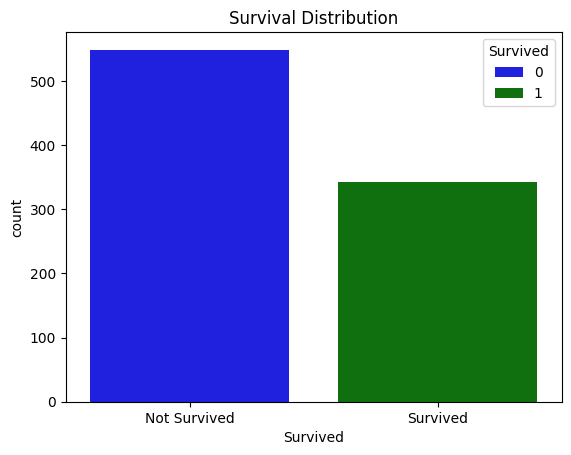

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Survived', hue='Survived', data=titanic_df, palette=["blue", "green"])
plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.title("Survival Distribution")
plt.show()

#### Passenger Class (Pclass):

In [17]:
titanic_df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Visualize the distribution of Pclass using a count plot.



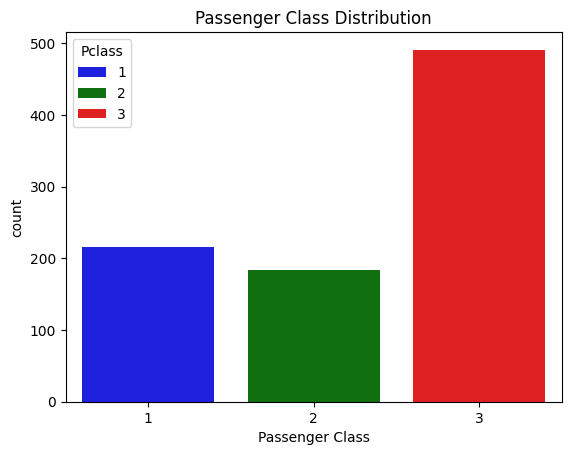

In [22]:
sns.countplot(x="Pclass", hue="Pclass", data=titanic_df, palette=["blue", "green", "red"])
plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.show()

Identify which class had the most passengers.



In [23]:
print(f"Class {titanic_df["Pclass"].mode()[0]} had the most passengers")

Class 3 had the most passengers


## Task 3: Bivariate and Multivariate Analysis

Bivariate analysis explores the relationship between two variables, specifically focusing on how other features relate to the target variable (Survived).

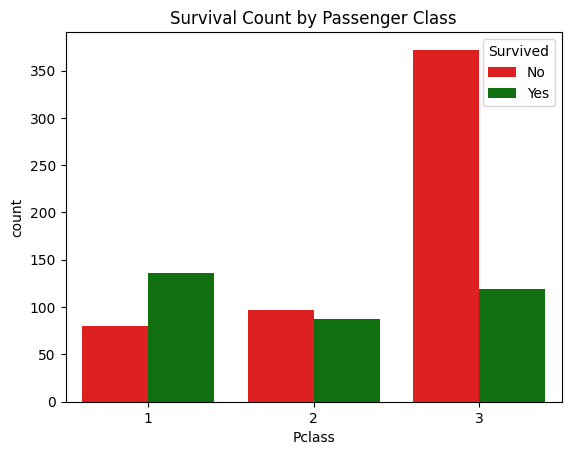

In [26]:
sns.countplot(x='Pclass', hue='Survived', data=titanic_df, palette= ['Red', 'Green'])
plt.title('Survival Count by Passenger Class')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

#### Survival by Sex:

Create a crosstabulation (or a grouped count) to show the count of survivors and non-survivors grouped by Sex.

In [27]:
pd.crosstab(titanic_df['Sex'], titanic_df['Survived'])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [28]:
titanic_df[['Sex', 'Survived']].groupby(['Sex'], as_index = False).value_counts()

,Sex,Survived,count
0,female,1,233
1,female,0,81
2,male,0,468
3,male,1,109


Visualize this relationship using a stacked bar chart or a grouped count plot.

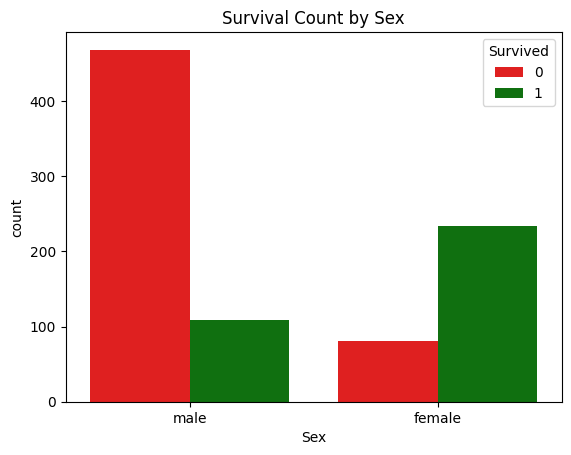

In [29]:
sns.countplot(x='Sex', hue='Survived', data=titanic_df, palette=['red', 'green'])
plt.title('Survival Count by Sex')
plt.show()

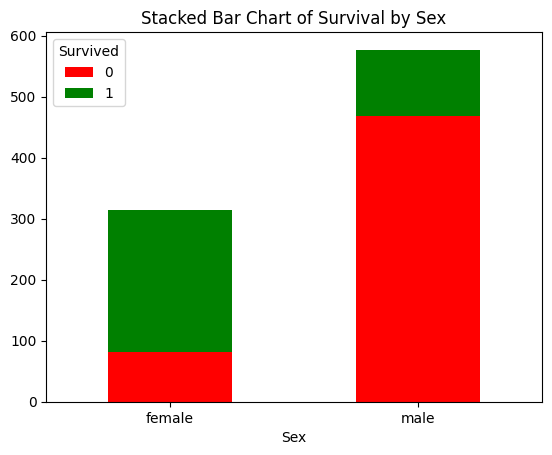

In [30]:
crosstab_sex_survived = pd.crosstab(titanic_df['Sex'], titanic_df['Survived'])
crosstab_sex_survived.plot(kind='bar', stacked=True, color=['red', 'green'])
plt.title('Stacked Bar Chart of Survival by Sex')
plt.xticks(rotation=0)
plt.show()

Question: Which gender had a significantly higher survival rate?

In [31]:
female_survival_rate = titanic_df[titanic_df['Sex'] == 'female']['Survived'].mean() * 100
male_survival_rate = titanic_df[titanic_df['Sex'] == 'male']['Survived'].mean() * 100
print(f"Female Survival Rate: {female_survival_rate:.2f}%")
print(f"Male Survival Rate: {male_survival_rate:.2f}%")
print("=="*40)
print("Based on these rates, females had a significantly higher survival rate.")
print("=="*40)

Female Survival Rate: 74.20%
Male Survival Rate: 18.89%
Based on these rates, females had a significantly higher survival rate.


#### Survival by Class (Pclass):

Calculate and visualize the survival rate for each Pclass.

In [32]:
class1 = titanic_df[titanic_df['Pclass'] == 1]['Survived'].mean()*100
class2 = titanic_df[titanic_df['Pclass'] == 2]['Survived'].mean()*100
class3 = titanic_df[titanic_df['Pclass'] == 3]['Survived'].mean()*100

print(f"Class 1 Survival Rate: {class1:.2f}%")
print(f"Class 2 Survival Rate: {class2:.2f}%")
print(f"Class 3 Survival Rate: {class3:.2f}%")

Class 1 Survival Rate: 62.96%
Class 2 Survival Rate: 47.28%
Class 3 Survival Rate: 24.24%


In [36]:
pclass_survival = titanic_df[['Pclass', 'Survived']].groupby(['Pclass'], as_index=False).mean().sort_values(by='Survived', ascending=False)
pclass_survival

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


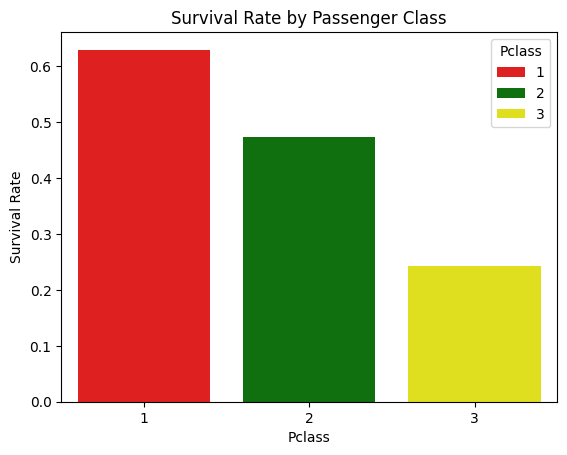

In [37]:
sns.barplot(x='Pclass', y='Survived', hue='Pclass', data=pclass_survival, palette=['Red', 'Green', 'Yellow'])
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

Question: Is there a clear correlation between ticket class and survival probability?

In [38]:
print(f"Class 1 Survival Rate: {class1:.2f}%")
print(f"Class 2 Survival Rate: {class2:.2f}%")
print(f"Class 3 Survival Rate: {class3:.2f}%")
print("=="*40)
print("Based on these rates, there is a clear correlation between ticket class and survival probability.")
print("Passengers in higher classes (Class 1) had a significantly higher survival rate compared to those in lower classes (Class 3).")
print("=="*40)

Class 1 Survival Rate: 62.96%
Class 2 Survival Rate: 47.28%
Class 3 Survival Rate: 24.24%
Based on these rates, there is a clear correlation between ticket class and survival probability.
Passengers in higher classes (Class 1) had a significantly higher survival rate compared to those in lower classes (Class 3).


#### Survival by Age:

Plot and compare the age distribution of survivors vs. non-survivors.

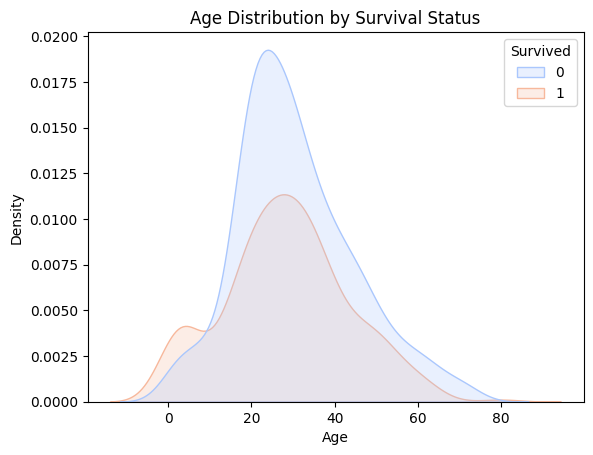

In [41]:
sns.kdeplot(data=titanic_df, x="Age", hue="Survived", fill=True, palette='coolwarm')
plt.title('Age Distribution by Survival Status')
plt.show()

Observation: What does the plot suggest about the survival chances of children and the elderly?

Age Distribution by Survival Status — 3 Key Observations

---

1. Children (Age 0–10)
- The **blue curve (Survived)** is **higher than the red curve (Did Not Survive)** in this range.
- **Children had better survival chances** — likely due to **"women and children first"** policy on the Titanic.

---

2. Young Adults (Age 20–40)
- The **blue curve peaks highest** here.
- The **red curve also peaks** but lower.
- **Most survivors were young adults**, but also many non-survivors — simply because this was the **largest age group** on the ship.

---

3. Elderly (Age 65+)
- The **red curve (Did Not Survive)** has a **heavier/longer tail** than the blue curve.
- **Elderly passengers were less likely to survive** — possibly due to physical difficulty in reaching lifeboats.

---

#### Survival by Port of Embarkation (Embarked):

Calculate and visualize the survival rate for each Embarked port.

In [42]:
embarked_survival = titanic_df[['Embarked', 'Survived']].groupby(['Embarked'], as_index=False).mean()
print("Survival Rate by Embarked Port:")
print(embarked_survival)

Survival Rate by Embarked Port:
  Embarked  Survived
0        C  0.553571
1        Q  0.389610
2        S  0.336957


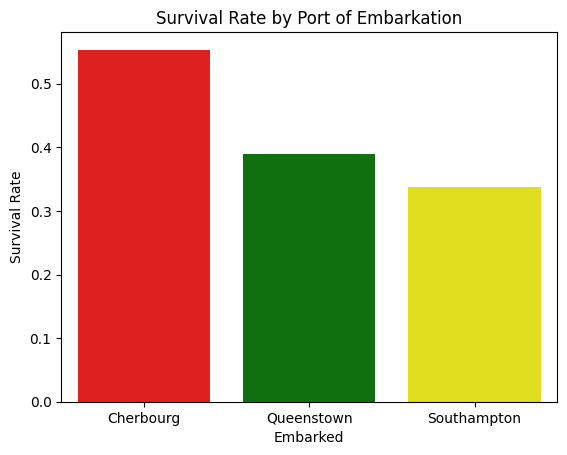

In [43]:
sns.barplot(x='Embarked', y='Survived', hue='Embarked', data=embarked_survival, palette=["Red", "Green", "Yellow"])
plt.title('Survival Rate by Port of Embarkation')
plt.ylabel('Survival Rate')
plt.xticks(ticks=[0, 1, 2], labels=['Cherbourg', 'Queenstown', 'Southampton'])
plt.show()

## Task 4: Conclusion and Insights

Based on your EDA, write a brief (3-5 sentences) conclusion summarizing the most significant factors affecting survival on the Titanic. Highlight the top 2-3 features that appear to be the strongest predictors of survival.

Key Factors Affecting Titanic Survival

Based on the EDA, **gender, passenger class, and age** are the strongest predictors of survival. **Women** survived significantly more due to the **"women and children first"** policy. **First-class passengers** had higher survival rates due to better lifeboat access. Finally, **children survived more** while the **elderly were less likely to survive**. These three features should be prioritized in any Titanic survival prediction model.